In [ ]:
import numpy as np
import pandas as pd

df=pd.read_csv('Rich_or_poor.csv',sep=';',skiprows=3,encoding='latin-1')
print(df)

                    Ê?ðñ?òê?÷ò?ðä?í àòàëûøòàðû  \
0                                          NaN   
1                          Êûðãûç Ðåñïóáëèêàñû   
2                                Áàòêåí îáëóñó   
3                            Æàëàë-Àáàä îáëóñó   
4                              Ûñûê-Ê?ë îáëóñó   
5                                 Íàðûí îáëóñó   
6   Îø îáëóñó (2013 æ. ÷åéèí Îø øààðû êîøóëóï)   
7                                 Òàëàñ îáëóñó   
8                                  ×?é îáëóñó    
9                                    Áèøêåê ø.   
10                                       Îø ø.   
11                                         NaN   
12                                         NaN   
13                                         NaN   
14                                         NaN   

                     Íàèìåíîâàíèå ïîêàçàòåëåé  \
0                                         NaN   
1                       Êûðãûçñêàÿ Ðåñïóáëèêà   
2                          Áàòêåíñêàÿ îáëàñòü   
3  

In [ ]:
cols_to_keep = ['Items'] + [str(year) for year in range(2019, 2023)]
df_final = df[cols_to_keep]
print(df_final)

                                             Items  2019  2020  2021  2022
0                                              NaN   NaN   NaN   NaN   NaN
1                                  Kyrgyz Republic  20,1  25,3  33,3  33,2
2                                    Batken oblast  32,6  34,7  40,7  48,5
3                                Jalal-Abat oblast  26,9  37,2  43,2  47,1
4                                 Yssyk-Kul oblast  24,4  27,9  38,1  31,2
5                                     Naryn oblast  28,1  36,8  39,2  42,0
6   Osh oblast  (until 2013 y. including Osh city)  14,0  18,8  23,8  19,9
7                                     Talas oblast  13,3  12,5  23,5  23,9
8                                      Chui oblast  19,1  25,4  27,0  26,1
9                                     Bishkek city  11,9  16,8  35,8  35,7
10                                        Osh city  20,7  14,7  28,6  26,6
11                                             NaN   NaN   NaN   NaN   NaN
12                       

In [ ]:
df_final.dropna()

,Items,2019,2020,2021,2022
1,Kyrgyz Republic,"20,1","25,3","33,3","33,2"
2,Batken oblast,"32,6","34,7","40,7","48,5"
3,Jalal-Abat oblast,"26,9","37,2","43,2","47,1"
4,Yssyk-Kul oblast,"24,4","27,9","38,1","31,2"
5,Naryn oblast,"28,1","36,8","39,2","42,0"
6,Osh oblast (until 2013 y. including Osh city),"14,0","18,8","23,8","19,9"
7,Talas oblast,"13,3","12,5","23,5","23,9"
8,Chui oblast,"19,1","25,4","27,0","26,1"
9,Bishkek city,"11,9","16,8","35,8","35,7"
10,Osh city,"20,7","14,7","28,6","26,6"


In [ ]:
# Выбираем только колонки с годами (например, с 3-й колонки и до конца)
year_columns = df.columns[3:]

for col in year_columns:
    # Очищаем и конвертируем каждый столбец
    df[col] = df[col].str.replace(' ', '').str.replace(',', '.').replace('-', np.nan).astype(float)

In [ ]:
print(year_columns)

Index(['2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023'],
      dtype='object')


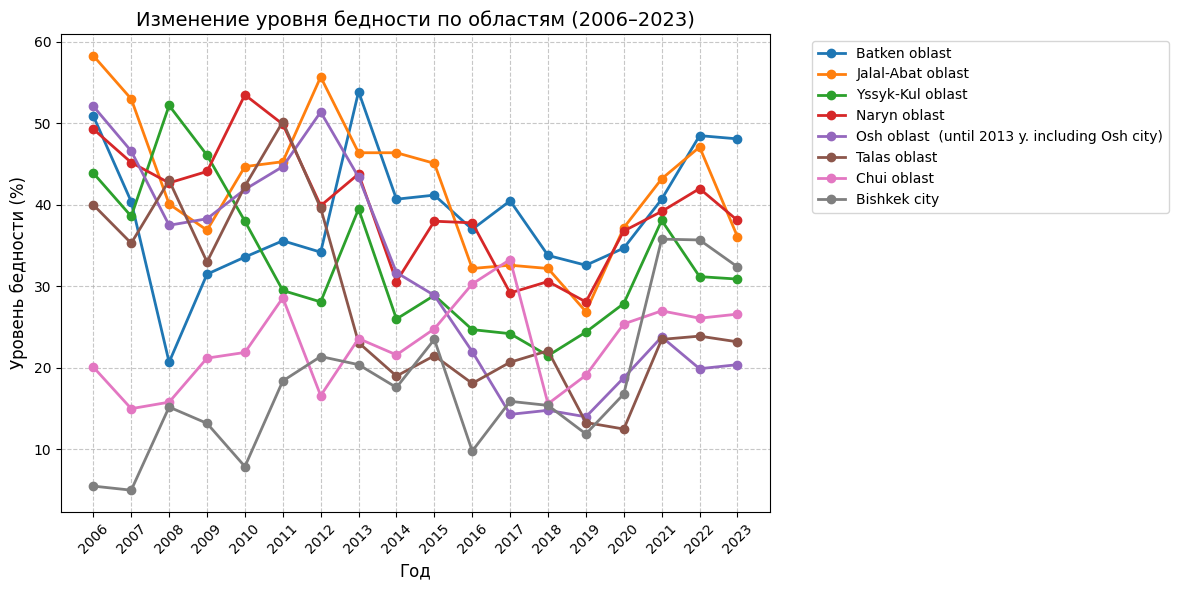

In [ ]:
import matplotlib.pyplot as plt

# Устанавливаем размер окна графика
plt.figure(figsize=(12, 6))

# Определяем список лет для построения графика, используя все года из очищенного df
years = year_columns.tolist()

# Подготавливаем данные для графика: выбираем нужные столбцы и удаляем строки с NaN значениями в годах
# Используем основной DataFrame `df`, который был очищен ранее для всех лет.
df_plot = df.dropna(subset=['Items'] + years).copy()

# Рисуем линии для каждого региона
# Мы исключаем общую строку 'Kyrgyz Republic', чтобы лучше видеть различия между областями
for region in df_plot['Items'].unique():
    if region != 'Kyrgyz Republic':
        region_data = df_plot[df_plot['Items'] == region]
        # Убедимся, что region_data содержит только нужные годы и преобразуем их в числовой формат
        plt.plot(years, region_data[years].values.flatten(), label=region, marker='o', linewidth=2)

# Настройка оформления
plt.title('Изменение уровня бедности по областям (2006–2023)', fontsize=14)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Уровень бедности (%)', fontsize=12)
plt.xticks(rotation=45) # Поворачиваем годы для удобства
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Выносим легенду за график
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2723/918856805.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_2023, x='2023', y='Items', palette='coolwarm')


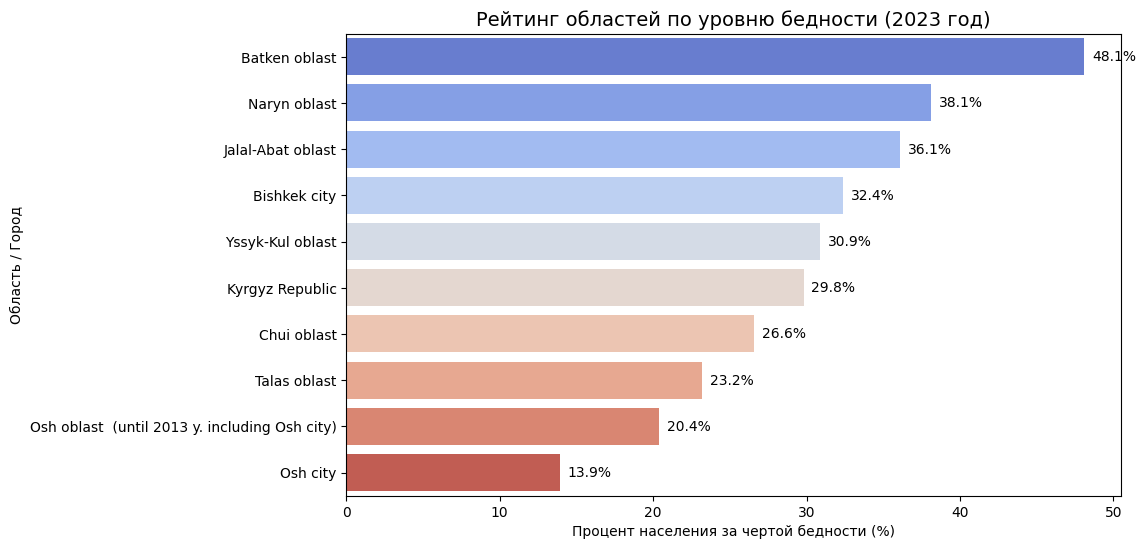

In [ ]:
import seaborn as sns

# Сортируем данные за 2023 год для красоты графика
# Используем df, который был очищен и содержит все года, включая 2023
df_2023 = df[['Items', '2023']].dropna(subset=['Items', '2023']).sort_values(by='2023', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_2023, x='2023', y='Items', palette='coolwarm')

# Добавляем подписи значений прямо на столбцы
for i, val in enumerate(df_2023['2023']):
    plt.text(val + 0.5, i, f'{val}%', va='center')

plt.title('Рейтинг областей по уровню бедности (2023 год)', fontsize=14)
plt.xlabel('Процент населения за чертой бедности (%)')
plt.ylabel('Область / Город')
plt.show()

In [ ]:
print(df_final.dtypes)

Items    object
2019     object
2020     object
2021     object
2022     object
dtype: object


In [ ]:
# 1. Создаем список лет (названия ваших колонок)
years = [str(y) for y in range(2019, 2023)]

# 2. Цикл для очистки и конвертации
for col in years:
    # str.replace(',', '.') — меняет запятую на точку
    # str.replace(' ', '') — удаляет пробелы
    # astype(float) — превращает текст в число
    df_final[col] = df_final[col].astype(str).str.replace(',', '.').str.replace(' ', '').astype(float)

# 3. Теперь вызываем статистику
print(df_final.describe().T)

      count   mean       std   min     25%    50%     75%   max
2019   10.0  21.11  6.886613  11.9  15.275  20.40  26.275  32.6
2020   10.0  25.01  9.182405  12.5  17.300  25.35  33.000  37.2
2021   10.0  33.32  7.187458  23.5  27.400  34.55  38.925  43.2
2022   10.0  33.42  9.842403  19.9  26.225  32.20  40.425  48.5


/tmp/ipykernel_2723/1721483013.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final[col] = df_final[col].astype(str).str.replace(',', '.').str.replace(' ', '').astype(float)
/tmp/ipykernel_2723/1721483013.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final[col] = df_final[col].astype(str).str.replace(',', '.').str.replace(' ', '').astype(float)
/tmp/ipykernel_2723/1721483013.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

In [ ]:
df_final.info()
print(df_final.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Items   10 non-null     object 
 1   2019    10 non-null     float64
 2   2020    10 non-null     float64
 3   2021    10 non-null     float64
 4   2022    10 non-null     float64
dtypes: float64(4), object(1)
memory usage: 732.0+ bytes
Items     object
2019     float64
2020     float64
2021     float64
2022     float64
dtype: object
